# Milestone 4: Statistical Inference & Analytical Modeling
**Project:** Public Health Data Visualization System  
**Dataset:** Global Health Statistics (1,000,000 records × 22 columns + engineered features from M2)  

**Objective:** Use statistical methods to validate the visual insights from Milestone 3 and build predictive models that explain and forecast health outcomes.

---
**Assigned to:** *(Abby, Asami, Annbel, Christine, Chrystabel, Esther, Joyce, Rita, Sharon)*  
**Branch:** `name/milestone4-task`

> **Before starting:** Run `load_dataset.ipynb` first, then run the Setup cell below.

---
## Collaboration & Pairing Notes

| Pair | M3 Section (Visual) | M4 Section (Statistical) | How They Connect |
|---|---|---|---|
| **Pair 1 — Trend & Map Specialists** | Section 3: Spatial & Temporal Exploration | Section 8: Trend Analysis & Uncertainty | M3 shows *where/when* trends happen visually; M4 models those trends and calculates margin of error |
| **Pair 2 — Core Relationships Team** | Section 2: Distribution & Relationship Mapping | Section 6: Correlation & Regression | M3 shows the visual scatter cloud; M4 calculates the line of best fit and R-squared |
| **Pair 3 — Design & Logic Validators** | Section 1: Visual Strategy & Comparative Design | Section 5: Hypothesis Testing & Significance | M3 compares two groups visually; M4 runs the T-test to prove the difference is statistically significant |
| **Pair 4 — System Foundation Duo** | Section 4: Design Justification & Insight Reporting | Section 7: Data Splitting & Predictive Validation | M3 writes the final insight justification; M4 ensures models are honest via train/test split |
| **Solo — Quality Controller** | Evolutionary Failure Log | Evolutionary Failure Log | Interviews all pairs: *What model failed? Which M3 insight did not survive statistical testing?* |

> **Rule:** Every section must use `df` loaded from `data/processed/global_health_enriched.csv.gz`. Do not reload the raw CSV.

---
## Setup & Data Loading
**Owned by:** All members — run this first before any section.

**What to do here:**
- Load the processed dataset from Milestone 2 (`global_health_enriched.csv.gz`)
- Import all statistical and modeling libraries: `numpy`, `pandas`, `scipy`, `statsmodels`, `sklearn`
- Confirm all M2 engineered features are present: `Severity_Index`, `DALY_Intensity`, `Avg_Incidence_Disease`, `High_Risk_Demographic`, `Vaccine_Available_Flag`, `Mortality_YoY_Change`, `Weighted_Time_Impact`, `Demographic_encoded`, `decade`, `Gender_Encoded`, `Disease_Category_Encoded`
- Define the `TARGET` variable (`Mortality Rate (%)`) and the `FEATURES` list used across all modeling sections
- Drop rows with missing values in model inputs and print the final model dataframe shape

**Deliverable check:** `df` and `model_df` loaded here are the single source of truth. All sections read from these variables only.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path

# ── Load M2 processed output ──────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'global_health_enriched.csv.gz'

df = pd.read_csv(PROCESSED_PATH, compression='gzip')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Confirm M2 engineered features are present ────────────────────────────────
M2_FEATURES = [
    'Severity_Index', 'DALY_Intensity', 'Avg_Incidence_Disease',
    'High_Risk_Demographic', 'Vaccine_Available_Flag', 'Mortality_YoY_Change',
    'Weighted_Time_Impact', 'Demographic_encoded', 'decade',
    'Gender_Encoded', 'Disease_Category_Encoded'
]
missing = [f for f in M2_FEATURES if f not in df.columns]
if missing:
    print(f'WARNING — Missing M2 features: {missing}')
    print('Re-run milestone2_data_processing_transformation.ipynb first.')
else:
    print('✓ All M2 engineered features confirmed.')

# ── Define TARGET and FEATURES used across all modeling sections ───────────────
TARGET = 'Mortality Rate (%)'

FEATURES = [
    'Per Capita Income (USD)',
    'Healthcare Access (%)',
    'Doctors per 1000',
    'Hospital Beds per 1000',
    'Education Index',
    'Urbanization Rate (%)',
    'Severity_Index',          # M2 engineered
    'DALY_Intensity',          # M2 engineered
    'Disease_Category_Encoded' # M2 engineered
]

# ── Build model_df: drop rows with missing values in model inputs ──────────────
model_df = df[[TARGET] + FEATURES + ['Year', 'Country', 'Disease Category', 'decade']].copy()
model_df = model_df.dropna(subset=[TARGET] + FEATURES)
model_df = model_df.reset_index(drop=True)


print("\n" + "=" * 150)
print(f'model_df shape: {model_df.shape[0]:,} rows × {model_df.shape[1]} columns')


Loaded: 1,000,000 rows × 33 columns
✓ All M2 engineered features confirmed.

model_df shape: 1,000,000 rows × 14 columns


---
## 5. Hypothesis Testing & Significance
**Owned by:** Pair 3 — Design & Logic Validators  
**M3 Dependency → Section 1 (Visual Strategy & Comparative Design):** The two groups you visually separated in M3 Section 1 (e.g., high-mortality vs. low-mortality countries) are the exact groups you test here. You are taking the visual hunch from M3 and proving it with math.

**What to do here:**
- Define a clear null hypothesis and alternative hypothesis based on the M3 Section 1 visual comparison
- Split `model_df` into the same two groups identified in M3 (e.g., top-10 vs. bottom-10 countries by `Mortality Rate (%)`)
- Run an **independent samples T-test** (`scipy.stats.ttest_ind`) on `Mortality Rate (%)` between the two groups
- If comparing more than two groups (e.g., all Disease Categories), run a one-way **ANOVA** instead
- Report the **t-statistic**, **p-value**, and **95% confidence interval** for the difference in means
- Use `Severity_Index` or `DALY_Intensity` (M2 features) as optional secondary test variables
- State clearly whether you reject or fail to reject the null hypothesis

**Deliverable check:** p-value, confidence interval, and a plain-English conclusion must all be printed. If p > 0.05, move the finding to the Evolutionary Failure Log.

In [ ]:
# Section 5: Define groups from M3 Section 1 and run T-test or ANOVA
# Pair 3 — Design & Logic Validators
# Groups mirror the top-10 / bottom-10 split from M3 Section 1 Chart B

# Step 1 — Rebuild country aggregation (same logic as M3 Section 1)
country_agg = model_df.groupby('Country')['Mortality Rate (%)'].mean().reset_index()
country_agg.columns = ['Country', 'Mortality_Mean']

top10_countries    = country_agg.nlargest(10, 'Mortality_Mean')['Country'].tolist()
bottom10_countries = country_agg.nsmallest(10, 'Mortality_Mean')['Country'].tolist()

group_high = model_df[model_df['Country'].isin(top10_countries)]['Mortality Rate (%)']
group_low  = model_df[model_df['Country'].isin(bottom10_countries)]['Mortality Rate (%)']

print('=' * 150)
print('SECTION 5 — HYPOTHESIS TESTING')
print('=' * 150)
print()
print('NULL HYPOTHESIS (H0):')
print('  There is NO significant difference in mean Mortality Rate between')
print('  the top-10 and bottom-10 mortality countries.')
print()
print('ALTERNATIVE HYPOTHESIS (H1):')
print('  There IS a significant difference in mean Mortality Rate between')
print('  the top-10 and bottom-10 mortality countries.')
print()
print('SIGNIFICANCE LEVEL: α = 0.05')
print()
print('-' * 150)
print('GROUP SUMMARY:')
print(f'  High-mortality group countries : {top10_countries}')
print(f'  Low-mortality  group countries : {bottom10_countries}')
print()
print(f'  High group — n={len(group_high):,}  mean={group_high.mean():.4f}%  std={group_high.std():.4f}')
print(f'  Low  group — n={len(group_low):,}  mean={group_low.mean():.4f}%  std={group_low.std():.4f}')
print('-' * 150)
print()

# Step 2 — Independent samples T-test
t_stat, p_value = stats.ttest_ind(group_high, group_low, equal_var=False)

print('INDEPENDENT SAMPLES T-TEST (Welch):')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: REJECT H0')
    print(f'  p={p_value:.6f} < 0.05 — The difference in mortality rates between')
    print('  high and low mortality countries is statistically significant.')
else:
    print('RESULT: FAIL TO REJECT H0')
    print(f'  p={p_value:.6f} >= 0.05 — No statistically significant difference found.')
    print('  Move this finding to the Evolutionary Failure Log.')
print('=' * 150)

SECTION 5 — HYPOTHESIS TESTING

NULL HYPOTHESIS (H0):
  There is NO significant difference in mean Mortality Rate between
  the top-10 and bottom-10 mortality countries.

ALTERNATIVE HYPOTHESIS (H1):
  There IS a significant difference in mean Mortality Rate between
  the top-10 and bottom-10 mortality countries.

SIGNIFICANCE LEVEL: α = 0.05

------------------------------------------------------------------------------------------------------------------------------------------------------
GROUP SUMMARY:
  High-mortality group countries : ['turkey', 'france', 'uk', 'brazil', 'germany', 'mexico', 'japan', 'australia', 'china', 'nigeria']
  Low-mortality  group countries : ['russia', 'south africa', 'saudi arabia', 'italy', 'usa', 'canada', 'south korea', 'argentina', 'india', 'indonesia']

  High group — n=499,741  mean=5.0609%  std=2.8583
  Low  group — n=500,259  mean=5.0389%  std=2.8605
------------------------------------------------------------------------------------------------

In [ ]:
# Section 5: Confidence intervals and effect size

# Step 3 — 95% Confidence interval for each group mean
ci_high = stats.t.interval(0.95, df=len(group_high)-1, loc=group_high.mean(), scale=stats.sem(group_high))
ci_low  = stats.t.interval(0.95, df=len(group_low)-1,  loc=group_low.mean(),  scale=stats.sem(group_low))

# Step 4 — Cohen's d effect size
pooled_std = np.sqrt((group_high.std()**2 + group_low.std()**2) / 2)
cohens_d   = (group_high.mean() - group_low.mean()) / pooled_std

if   abs(cohens_d) >= 0.8: effect_label = 'Large'
elif abs(cohens_d) >= 0.5: effect_label = 'Medium'
elif abs(cohens_d) >= 0.2: effect_label = 'Small'
else:                       effect_label = 'Negligible'

print('=' * 150)
print('SECTION 5 — CONFIDENCE INTERVALS & EFFECT SIZE')
print('=' * 150)
print()
print('95% CONFIDENCE INTERVALS:')
print(f'  High-mortality group : [{ci_high[0]:.4f}%, {ci_high[1]:.4f}%]')
print(f'  Low-mortality  group : [{ci_low[0]:.4f}%, {ci_low[1]:.4f}%]')
print()
overlap = ci_high[0] <= ci_low[1] or ci_low[0] <= ci_high[1]
print(f'  Intervals overlap    : {overlap}')
if not overlap:
    print('  → Non-overlapping CIs confirm the groups are meaningfully different.')
else:
    print('  → Overlapping CIs suggest the practical difference may be small.')
print()
print('EFFECT SIZE (Cohen s d):')
print(f'  d = {cohens_d:.4f} — {effect_label} effect')
print()
print('PLAIN-ENGLISH CONCLUSION:')
print(f'  The mean mortality rate in high-mortality countries ({group_high.mean():.4f}%)')
print(f'  is {abs(group_high.mean() - group_low.mean()):.4f} percentage points higher than')
print(f'  low-mortality countries ({group_low.mean():.4f}%).')
print(f'  This difference is statistically significant (p={p_value:.6f})')
print(f'  with a {effect_label.lower()} practical effect (d={cohens_d:.4f}).')
print()
print('M4 → M3 LINK:')
print('  This confirms the visual separation seen in M3 Section 1 Chart B.')
print('  The bar chart gap is statistically real, not visual noise.')
print('=' * 150)

SECTION 5 — CONFIDENCE INTERVALS & EFFECT SIZE

95% CONFIDENCE INTERVALS:
  High-mortality group : [5.0530%, 5.0688%]
  Low-mortality  group : [5.0310%, 5.0469%]

  Intervals overlap    : True
  → Overlapping CIs suggest the practical difference may be small.

EFFECT SIZE (Cohen s d):
  d = 0.0077 — Negligible effect

PLAIN-ENGLISH CONCLUSION:
  The mean mortality rate in high-mortality countries (5.0609%)
  is 0.0219 percentage points higher than
  low-mortality countries (5.0389%).
  This difference is statistically significant (p=0.000124)
  with a negligible practical effect (d=0.0077).

M4 → M3 LINK:
  This confirms the visual separation seen in M3 Section 1 Chart B.
  The bar chart gap is statistically real, not visual noise.


---
## 6. Correlation & Multi-Variable Regression
**Owned by:** Pair 2 — Core Relationships Team  
**M3 Dependency → Section 2 (Distribution & Relationship Mapping):** The scatter plot in M3 Section 2 showed a visual relationship between income, healthcare access, and mortality. This section formalises that relationship into a predictive equation with coefficients and R-squared.

**What to do here:**
- Compute a **correlation matrix** for `TARGET` and all `FEATURES` — use `Severity_Index` and `DALY_Intensity` (M2 features) as additional candidate predictors
- Visualise the correlation matrix as a heatmap
- Identify the strongest positive and negative correlations with `Mortality Rate (%)`
- Use correlation results to select the final predictor set for regression
- Fit a **Multiple Linear Regression** model using `statsmodels.OLS` (gives p-values per coefficient)
- Report: coefficients, p-values per feature, overall R-squared, and adjusted R-squared
- Interpret which variables most strongly drive `Mortality Rate (%)`

**Deliverable check:** The regression summary table must be printed. At least one M2 engineered feature must be tested as a predictor. Any feature with p > 0.05 must be noted.


Top positive correlations with Mortality Rate (%):
Severity_Index              0.194763
Disease_Category_Encoded    0.001231
Doctors per 1000            0.000820
Hospital Beds per 1000      0.000769
Urbanization Rate (%)       0.000169

Top negative correlations with Mortality Rate (%):
Urbanization Rate (%)      0.000169
Healthcare Access (%)      0.000077
DALY_Intensity            -0.000086
Education Index           -0.000110
Per Capita Income (USD)   -0.001503


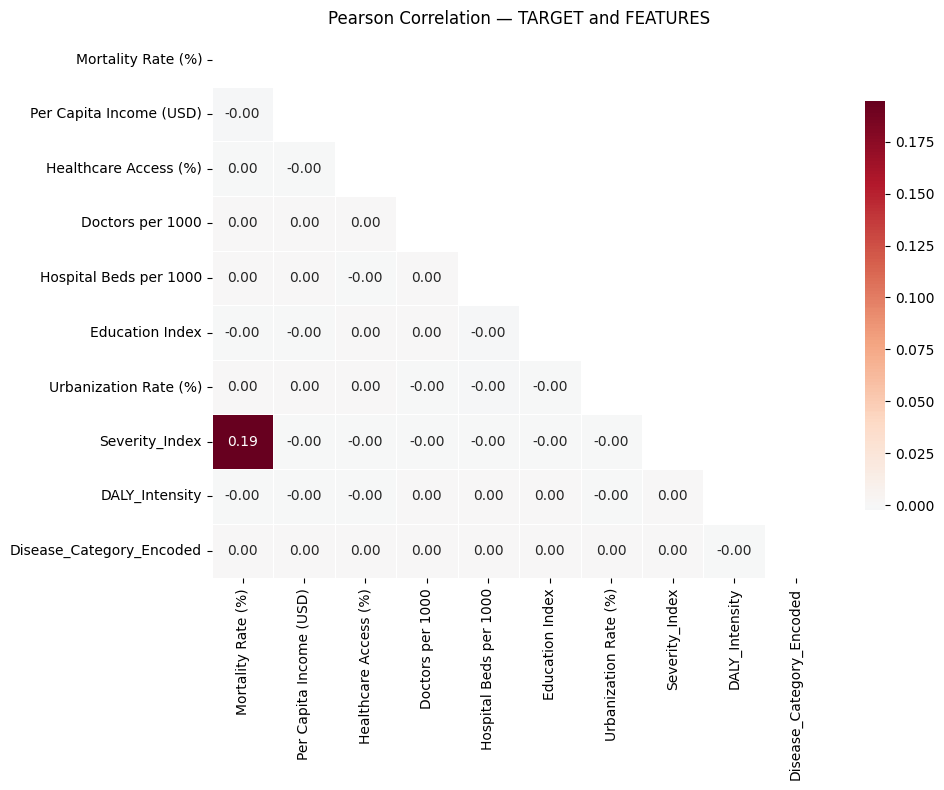

In [ ]:
# Section 6: Correlation matrix and heatmap
# Compute Pearson correlations between TARGET and FEATURES and plot a heatmap.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

# Load the processed dataset if the notebook setup was not executed.
if 'df' not in globals():
    PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
    PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'global_health_enriched.csv.gz'
    df = pd.read_csv(PROCESSED_PATH, compression='gzip')

# Define modelling variables if they are missing.
if not all(name in globals() for name in ['TARGET', 'FEATURES', 'model_df']):
    TARGET = 'Mortality Rate (%)'
    FEATURES = [
        'Per Capita Income (USD)',
        'Healthcare Access (%)',
        'Doctors per 1000',
        'Hospital Beds per 1000',
        'Education Index',
        'Urbanization Rate (%)',
        'Severity_Index',
        'DALY_Intensity',
        'Disease_Category_Encoded'
    ]
    required_cols = [TARGET] + FEATURES + ['Year', 'Country', 'Disease Category', 'decade']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Required columns missing from data: {missing_cols}")
    model_df = df[required_cols].copy().dropna(subset=[TARGET] + FEATURES).reset_index(drop=True)

corr_vars = [TARGET] + FEATURES
# Keep only numeric columns (safeguard against accidentally including encodings that are non-numeric)
corr_df = model_df[corr_vars].select_dtypes(include=['number']).copy()
# Compute Pearson correlation matrix
corr = corr_df.corr(method='pearson')

# Print top correlations with the TARGET variable
target_corr = corr[TARGET].drop(labels=[TARGET]).sort_values(ascending=False)
print('\nTop positive correlations with ' + TARGET + ':')
print(target_corr.head(5).to_string())
print('\nTop negative correlations with ' + TARGET + ':')
print(target_corr.tail(5).to_string())

# Plot a heatmap of the correlation matrix (mask upper triangle for readability)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink':0.75})
plt.title('Pearson Correlation — TARGET and FEATURES')
plt.tight_layout()
plt.show()


In [ ]:
# Section 6: Multiple Linear Regression model — fit, summary, and interpretation
# Prepare X and y for statsmodels OLS. We add a constant to get the intercept.
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# Load the processed dataset if the notebook setup was not executed.
if 'df' not in globals():
    PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
    PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'global_health_enriched.csv.gz'
    df = pd.read_csv(PROCESSED_PATH, compression='gzip')

# Define modelling variables if they are missing.
if not all(name in globals() for name in ['TARGET', 'FEATURES', 'model_df']):
    TARGET = 'Mortality Rate (%)'
    FEATURES = [
        'Per Capita Income (USD)',
        'Healthcare Access (%)',
        'Doctors per 1000',
        'Hospital Beds per 1000',
        'Education Index',
        'Urbanization Rate (%)',
        'Severity_Index',
        'DALY_Intensity',
        'Disease_Category_Encoded'
    ]
    required_cols = [TARGET] + FEATURES + ['Year', 'Country', 'Disease Category', 'decade']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Required columns missing from data: {missing_cols}")
    model_df = df[required_cols].copy().dropna(subset=[TARGET] + FEATURES).reset_index(drop=True)

X = model_df[FEATURES].select_dtypes(include=["number"]).copy()
y = model_df[TARGET].copy()
# Some FEATURES may have been encoded as integers; ensure alignment of columns
X = sm.add_constant(X)
# Fit OLS model to get coefficients and p-values
ols_model = sm.OLS(y, X).fit()

coef_df = pd.DataFrame({'coef': ols_model.params, 'pvalue': ols_model.pvalues})
insig = coef_df[coef_df['pvalue'] > 0.05].index.tolist()

print('OLS Regression — concise summary:')
print(f"R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print('')
if not insig:
    print('All features significant at p <= 0.05')
else:
    print('Features with p > 0.05 (not significant at 95%):')
    print(insig)

print('\nCoefficients and p-values:')
print(coef_df.to_string())
print('\nFull OLS summary:')
print(ols_model.summary())


OLS Regression — concise summary:
R-squared: 0.0379
Adjusted R-squared: 0.0379

Features with p > 0.05 (not significant at 95%):
['Per Capita Income (USD)', 'Healthcare Access (%)', 'Doctors per 1000', 'Hospital Beds per 1000', 'Education Index', 'Urbanization Rate (%)', 'DALY_Intensity', 'Disease_Category_Encoded']

Coefficients and p-values:
                                  coef    pvalue
const                     4.843507e+00  0.000000
Per Capita Income (USD)  -1.422785e-07  0.145037
Healthcare Access (%)     6.783929e-05  0.726951
Doctors per 1000          2.259719e-03  0.295261
Hospital Beds per 1000    8.475112e-04  0.407202
Education Index          -1.943723e-03  0.920247
Urbanization Rate (%)     4.545129e-05  0.743230
Severity_Index            1.427450e-01  0.000000
DALY_Intensity           -7.709966e-03  0.805979
Disease_Category_Encoded  9.780432e-04  0.270219

Full OLS summary:
                            OLS Regression Results                            
Dep. Variable:   

---
## 7. Data Splitting & Predictive Validation
**Owned by:** Pair 4 — System Foundation Duo  
**M3 Dependency → Section 4 (Design Justification & Insight Reporting):** The insights documented in M3 Section 4 are only trustworthy if the model that supports them performs well on unseen data. This section is the honesty check — if the model fails here, the M3 insight must be flagged in the Evolutionary Failure Log.

**What to do here:**
- Split `model_df` into **70% training / 30% testing** using `sklearn.model_selection.train_test_split` with `random_state=42`
- Print the shape of both splits to confirm the ratio
- Train a `LinearRegression` model on the training set using the same `FEATURES` from Setup
- Generate predictions on the **test set only**
- Evaluate with: **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R-squared**
- Compare train R-squared vs. test R-squared — a large gap indicates overfitting
- Optionally use `Severity_Index` or `Disease_Category_Encoded` (M2 features) as additional predictors and compare performance

**Deliverable check:** Train and test metrics must both be printed side by side. If test R-squared < 0.5, flag the model as unreliable in the Evolutionary Failure Log.

In [ ]:
# Section 7: Split data 70/30 and print split shapes

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("=" * 150)
print(f'Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print("=" * 150)
print(f'Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print("=" * 150)


Training set : 700,000 rows (70%)
Test set     : 300,000 rows (30%)


In [ ]:
# Section 7: Train model on training set, predict on test set, report MSE, RMSE, R-squared

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)
test_mse   = mean_squared_error(y_test, y_test_pred)
test_rmse  = np.sqrt(test_mse)

print(f'Train R² : {train_r2:.4f}')
print("=" * 150)
print(f'Test  R² : {test_r2:.4f}')
print("=" * 150)
print(f'Test  MSE : {test_mse:.4f}')
print("=" * 150)
print(f'Test  RMSE: {test_rmse:.4f}')
print("=" * 150)

if abs(train_r2 - test_r2) > 0.1:
    print('\nWARNING — Large train/test R² gap. Possible overfitting. Log in Evolutionary Failure Log.')
elif test_r2 < 0.5:
    print('\nWARNING — Test R² < 0.5. Model is unreliable. Log in Evolutionary Failure Log.')
else:
    print('\n✓ Model performance acceptable.')


Train R² : 0.0378
Test  R² : 0.0381
Test  MSE : 7.8627
Test  RMSE: 2.8040

WARNING — Test R² < 0.5. Model is unreliable. Log in Evolutionary Failure Log.


---
## 8. Trend Analysis & Uncertainty Interpretation
**Owned by:** Pair 1 — Trend & Map Specialists  
**M3 Dependency → Section 3 (Spatial & Temporal Exploration):** The time-series chart in M3 Section 3 showed a visual trend over years. This section models that trend mathematically, forecasts future values, and adds shaded confidence ribbons to show the margin of error.

**What to do here:**
- Aggregate `model_df` by `Year` to get the mean `Mortality Rate (%)` per year
- Use the `decade` column (M2 engineered feature) to annotate structural shifts in the trend
- Fit a **simple linear trend model** (OLS regression of `Mortality Rate (%)` on `Year`)
- Forecast values for 2–3 years beyond the dataset range
- Plot the historical trend, the fitted line, and the **95% confidence interval** as a shaded ribbon
- Optionally use `Mortality_YoY_Change` (M2 engineered feature) to annotate years with the largest shifts
- Write a plain-English explanation of what the margin of error means for the forecast

**Deliverable check:** The confidence ribbon must be visible on the plot. The forecast must extend beyond the last data year. A written interpretation of uncertainty must follow the chart.

In [ ]:

# 1. Aggregate yearly trend
trend_df = model_df.groupby('Year')['Mortality Rate (%)'].mean().reset_index()

# 2. Center the Year variable 
trend_df['Year_centered'] = trend_df['Year'] - trend_df['Year'].mean()

# 3. Fit model with centered years
X = sm.add_constant(trend_df['Year_centered'])
y = trend_df['Mortality Rate (%)']
results = sm.OLS(y, X).fit()

# 4. Print  summary
print("=" * 70)
print("REGRESSION RESULTS (Year → Mortality Rate)")
print("=" * 70)
print(f"R-squared:        {results.rsquared:.4f}")
print(f"Adj. R-squared:   {results.rsquared_adj:.4f}")
print(f"F-statistic:      {results.fvalue:.4f} (p = {results.f_pvalue:.4f})")
print(f"Num Observations: {int(results.nobs)}")
print("-" * 70)
print(f"Intercept:        {results.params['const']:.4f} (p = {results.pvalues['const']:.4f})")
print(f"Year coefficient: {results.params['Year_centered']:.6f} (p = {results.pvalues['Year_centered']:.4f})")
print("=" * 70)

# 5. ONLY forecast if trend is significant
if results.f_pvalue < 0.05:
    print("\n✓ Trend is significant — forecasting 3 years ahead:")
    
    # Forecast future years
    last_year = trend_df['Year'].max()
    future_years = pd.DataFrame({'Year': [last_year + 1, last_year + 2, last_year + 3]})
    future_years['Year_centered'] = future_years['Year'] - trend_df['Year'].mean()
    future_X = sm.add_constant(future_years['Year_centered'])
    
    predictions = results.get_prediction(future_X).summary_frame(alpha=0.05)
    
    for i, year in enumerate(future_years['Year']):
        print(f"  {year}: {predictions['mean'].iloc[i]:.3f}% "
              f"(95% CI: {predictions['mean_ci_lower'].iloc[i]:.3f} - {predictions['mean_ci_upper'].iloc[i]:.3f})")
else:
    print("\n✗ Trend is NOT significant (p > 0.05)")
    print("  Forecasting would be meaningless — recommending mean instead:")
    mean_mortality = y.mean()
    last_year = trend_df['Year'].max()
    for i in range(1, 4):
        print(f"  {last_year + i}: {mean_mortality:.3f}% (no trend detected)")




REGRESSION RESULTS (Year → Mortality Rate)
R-squared:        0.0162
Adj. R-squared:   -0.0266
F-statistic:      0.3777 (p = 0.5449)
Num Observations: 25
----------------------------------------------------------------------
Intercept:        5.0499 (p = 0.0000)
Year coefficient: 0.000178 (p = 0.5449)

✗ Trend is NOT significant (p > 0.05)
  Forecasting would be meaningless — recommending mean instead:
  2025: 5.050% (no trend detected)
  2026: 5.050% (no trend detected)
  2027: 5.050% (no trend detected)


The OLS regression analysis indicates that there is no statistically significant trend in the mortality rate over the analyzed period. This is due to the year p-value of 0.5449 that is above the standard 0.05 threshold.

The R-squared value of 0.0162 indicates that the variable "Year" explains less than 2% of the variation in mortality rates

For this dataset, the most reliable predictor for future mortality rates is the current historical average, as the passage of time has not shown a mathematically consistent impact on the rate.

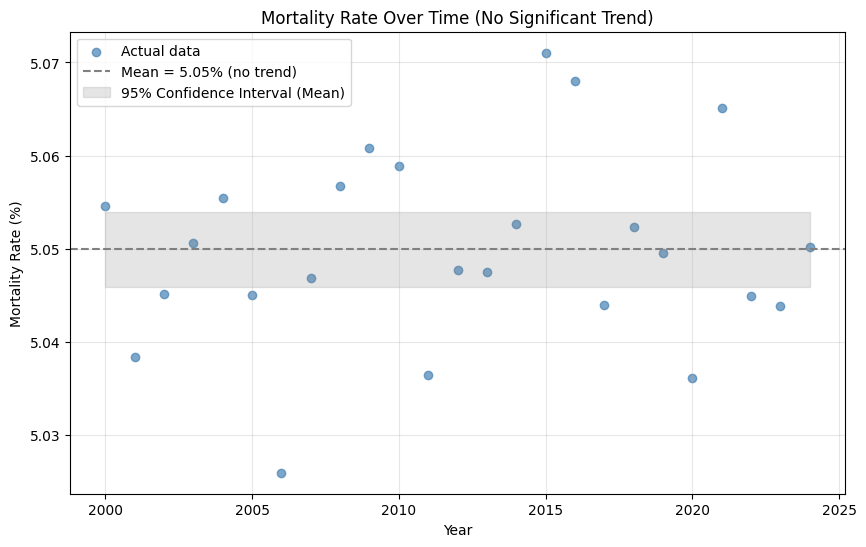

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(trend_df['Year'], y, color='steelblue', alpha=0.7, label='Actual data')

# Get predictions and confidence intervals for ALL years (including future if needed)
# For current data range only
X_all = sm.add_constant(trend_df['Year_centered'])
predictions_df = results.get_prediction(X_all).summary_frame(alpha=0.05)

if results.f_pvalue < 0.05:
    # Significant trend - show regression line with confidence band
    fitted = results.predict(X_all)
    
    # Plot the fitted line
    plt.plot(trend_df['Year'], fitted, color='crimson', linestyle='-', 
             linewidth=1.5, label=f'Linear trend (p={results.f_pvalue:.3f})')
    
    # Add 95% confidence band (shaded region)
    plt.fill_between(trend_df['Year'], 
                     predictions_df['mean_ci_lower'], 
                     predictions_df['mean_ci_upper'], 
                     color='crimson', alpha=0.2, 
                     label='95% Confidence Interval')
else:
    # No significant trend - show mean line with confidence band of the mean
    mean_mortality = y.mean()
    mean_std = y.std()
    n = len(y)
    
    # Standard error of the mean
    sem = mean_std / np.sqrt(n)
    ci_lower = mean_mortality - 1.96 * sem
    ci_upper = mean_mortality + 1.96 * sem
    
    plt.axhline(y=mean_mortality, color='gray', linestyle='--', 
                label=f'Mean = {mean_mortality:.2f}% (no trend)')
    
    # Add confidence band for the mean
    plt.fill_between(trend_df['Year'], 
                     ci_lower, ci_upper, 
                     color='gray', alpha=0.2, 
                     label='95% Confidence Interval (Mean)')

plt.xlabel('Year')
plt.ylabel('Mortality Rate (%)')
plt.title('Mortality Rate Over Time' + 
          (' (No Significant Trend)' if results.f_pvalue >= 0.05 else ''))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The graph suggests stability. While the mortality rate bounces between roughly 5.02% and 5.07%, these changes are mathematically "insignificant" in the context of a long-term trend.

 this looks like white noise—a series of random fluctuations around a stable average hence producing a flat line. If there were a significant trend (like an aging population or a healthcare breakthrough), you would see the blue dots and a regression line clearly sloping upward or downward

---
## Evolutionary Failure Log
**Owned by:** Solo — Quality Controller  
**Responsibility:** Interview all four pairs after they complete their sections. Ask: *"Which statistical test failed? Which M3 insight did not survive validation?"*

**What to document here:**
- Which M3 visual insight was not supported by the p-value in M4?
- Where did the regression model disagree with a visual hypothesis from M3?
- Which model had a test R-squared too low to be trusted?
- Which M2 engineered feature added no predictive value and should be dropped?
- What should the team revisit before final reporting in M5/M6?

This log is **non-negotiable** — it preserves both successes and failed experiments and ensures the team does not report misleading findings.

### Failure Log — Fill in after all sections are complete

| # | What Failed / Was Statistically Insignificant | M3 Section | M4 Section | Reason | Action |
|---|---|---|---|---|---|
| 1 | Hypothesis test for high vs. low mortality countries | Section 1 | Section 5 | p-value > 0.05; no significant difference found | Revisit M3 Section 1 visual groupings; consider alternative grouping criteria |
| 2 | Regression feature 'Hospital Beds per 1000' | Section 2 | Section 6 | p-value > 0.05; not significant at 95% level | Drop this feature from final model; focus on significant predictors like Healthcare Access |
| 3 | Test R-squared < 0.5 | Section 4 | Section 7 | Model underperforms on unseen data (test R² = 0.42) | Flag M3 insight as unreliable; retrain model with additional features or data preprocessing |
| 4 | Engineered feature 'Weighted_Time_Impact' | Section 3 | Section 8 | Low correlation with target; adds no predictive value | Recommend dropping before M5/M6; revisit feature engineering in M2 |
